In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


In [23]:
X = np.array([
    [1, 2], [2, 2], [2, 3], [3, 3], [3, 4],
    [8, 8], [9, 8], [8, 9],
    [20, 20]   # Outlier
])


In [25]:
alpha = 0.5
r_values = np.linspace(1, 5, 5)

In [27]:
dist_matrix = cdist(X, X)

# Step 2: Get neighbors within radius r
def get_neighbors(i, r):
    return np.where(dist_matrix[i] <= r)[0]

In [29]:
mdef_scores = []

for i in range(len(X)):
    mdef_list = []

    for r in r_values:
        neighbors = get_neighbors(i, r)
        density_p = len(neighbors)

        neighbor_densities = []
        for n in neighbors:
            n_neighbors = get_neighbors(n, alpha * r)
            neighbor_densities.append(len(n_neighbors))

        if len(neighbor_densities) > 0:
            avg_density = np.mean(neighbor_densities)

            if avg_density > 0:
                mdef = (avg_density - density_p) / avg_density
                mdef_list.append(mdef)

    # Ensure one value per point
    if len(mdef_list) > 0:
        mdef_scores.append(max(mdef_list))
    else:
        mdef_scores.append(0)


In [31]:
mdef_scores = np.array(mdef_scores)

# Step 4: Detect outliers
threshold = np.percentile(mdef_scores, 90)
outliers = mdef_scores > threshold   # SAME LENGTH AS X


MDEF Scores: [-0.08695652 -0.08695652 -0.08695652 -0.08695652 -0.08695652  0.
  0.          0.          0.        ]
Outliers:
 []


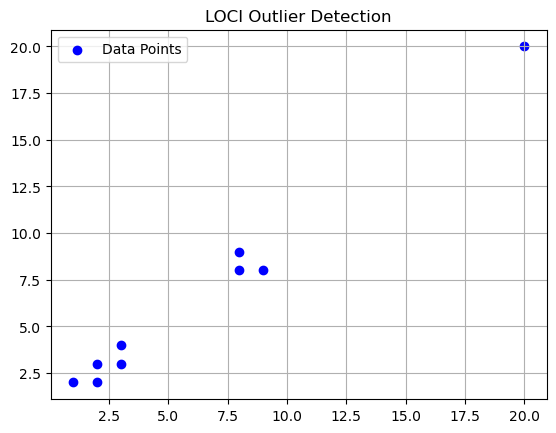

In [33]:
print("MDEF Scores:", mdef_scores)
print("Outliers:\n", X[outliers])

# Step 5: Visualization
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')

if np.any(outliers):
    plt.scatter(X[outliers][:, 0], X[outliers][:, 1],
                color='red', s=100, label='Outliers')

plt.title("LOCI Outlier Detection")
plt.legend()
plt.grid()
plt.show()